## Train Q-network with k-of-n CRF

- sample a batch from the replay buffer
- given the current policy select least k reward models from the ensemble --> replace reward $R$
- 

In [1]:
import numpy as np
import gymnasium as gym
import torch
import os
import random
import sys
import matplotlib.pylab as plt

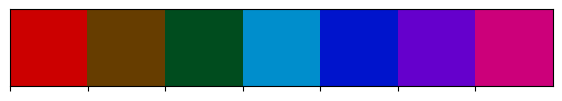

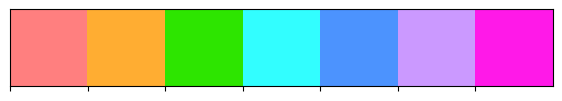

In [2]:
SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.replay_buffer import TorchReplayMemory
from src.critic import MonRoomCNN
from src.wrappers.env_wrappers import WallObs, WindowViewObs, MultiChannel
from src.wrappers.monitor_wrappers import RoomMonitor

## parameters

In [10]:
batch_size = 128
grid_size = [10, 10]
n_mdp_actions = 6
window_size = 3
dryness = 0.05
gamma = 0.99
q_lr = 0.0001
r_lr = 0.0001
center_indx = window_size // 2

kernal_0 = 2 if window_size == 3 else 3
kernal_1 = 1 if window_size == 3 else 2
update_target_freq = 5

device = "mps:0"
n_rows, n_colums = grid_size

main_dir = "../general_models/Plants/reward_model/{}_{}_channel/dry_{}/room/window_{}/q_lr_{}/reward_lr_{}".format(
    n_rows, n_colums, dryness, window_size, q_lr, r_lr)

## load replay buffer

In [4]:
seed = 4
replay_buffer_1 = TorchReplayMemory(int(1e6))
replay_buffer_1.load(main_dir + "/checkpoints_{}/".format(1), seed)

replay_buffer_2 = TorchReplayMemory(int(1e6))
replay_buffer_2.load(main_dir + "/checkpoints_{}/".format(2), seed)

replay_buffer_3 = TorchReplayMemory(int(1e6))
replay_buffer_3.load(main_dir + "/checkpoints_{}/".format(3), seed)

### load reward models

In [5]:
n_r_models = 500
trained_models = []
for r in range(n_r_models):
    trained_models.append(torch.load(main_dir + "/ensemble_reward_models/reward_model_{}".format(r)))

## sample batch

In [11]:
def select_action(q_values) -> int:
    """Choose an action from a Q value distribution/ break ties to a random action"""
    indices = np.argwhere(q_values == np.max(q_values))
    return random.choice(indices)[0]

def sort_and_k_least (array, k):
    '''
    sort a tensor from small value to big value and select lowest k values
    Inputs:
    array: (tesnor) tensor we want to sort it
    k: (int) size of lowest values
    return:
    numpy array (shape (k, ))
    '''
    return array.argsort()[:k]

def evalaute_obs(obs, models):
    rewards = torch.zeros((len(models), obs.shape[0], n_mdp_actions), device=device)
    with torch.no_grad():
        for i, model in enumerate(models):
            rewards[i] = model._network(obs)
    return rewards

In [12]:
reward_prams = {
    "r0": 0,
    "lr": 1e-4, #1.0
    "kernel_size_0": kernal_0,
    "kernel_size_1": kernal_1,
    "flatten": True,
    "stride_0": 1,
    "stride_1": 1,
    "device": device,
}

In [13]:
env_id = "gym_monitor/Plants-Watering-v1"

plants_env = gym.make(
    env_id,
    grid_size=grid_size,
    n_plants=8,
    plants_dryness_prob=dryness,
    dry_difference=0.5,
    agent_start_pos=None,
    max_episode_steps=100,
    render_mode = "human",
    add_new_plants=False,
    add_more_plants=True,
    )

wall_env = WallObs(plants_env, grid_size=grid_size, n_walls=10)
window_env = WindowViewObs(wall_env, window_size=window_size)
channel_env = MultiChannel(window_env, normalize_obs=True)
env = RoomMonitor(channel_env, full_monitor=False, monitor_cost=0.0, monitor_column_ind=5)

critic = MonRoomCNN(env_id, env.observation_space, env.action_space, dir_name=main_dir, on_policy= False,
  q0= 0,
  gamma= 0.99,
  lr= 1e-4,
  strategy= "reward_model",
  unseen_r_value= 0.0,
  kernel_size_0= kernal_0,
  kernel_size_1= kernal_1,
  stride_0= 1,
  stride_1= 1,
  device=device,
  reward_model=reward_prams,
)
critic.reset()

/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:29: UserWarning: WARN: It seems a Box observation space is an image but the `dtype` is not `np.uint8`, actual type: float64. If the Box observation space is not an image, we recommend flattening the observation to have only a 1D vector.
  logger.warn(
/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:34: UserWarning: WARN: It seems a Box observation space is an image but the lower and upper bounds are not [0, 255]. Actual lower bound: 0.0, upper bound: 1.0. Generally, CNN policies assume observations are within that range, so you may encounter an issue if the observation values are not.
  logger.warn(


In [9]:
k = 1
n = 50
n_itr = n_r_models // n

In [10]:
critic.reset()
for itr in range(int(1e5)):
    replay_buffer = np.random.choice([replay_buffer_1, replay_buffer_2, replay_buffer_3])
    sampled_batch = replay_buffer.process_batch(replay_buffer.sample(batch_size), device=device)

    indx = np.random.choice(np.arange(n_r_models), n, replace=False)
    selected_models = [trained_models[i] for i in indx]

    n_rewards = evalaute_obs(sampled_batch["mdp_obs"][:, :, center_indx, center_indx], selected_models)
    with torch.no_grad():
        qs = critic._q_network.forward(sampled_batch["mdp_obs"], sampled_batch["mon_obs"])
    policy = torch.softmax(qs, 1)
    policy_values =  torch.sum(torch.sum(n_rewards * policy, 2), 1)
    k_rewards = torch.mean(n_rewards[sort_and_k_least(policy_values.cpu().numpy(), k)], 0)
    _, _ = critic.optimize_policy_model(
        sampled_batch, update_target=itr % update_target_freq, monitor_state=True, rewards=k_rewards,
    )

critic.save(seed=150)

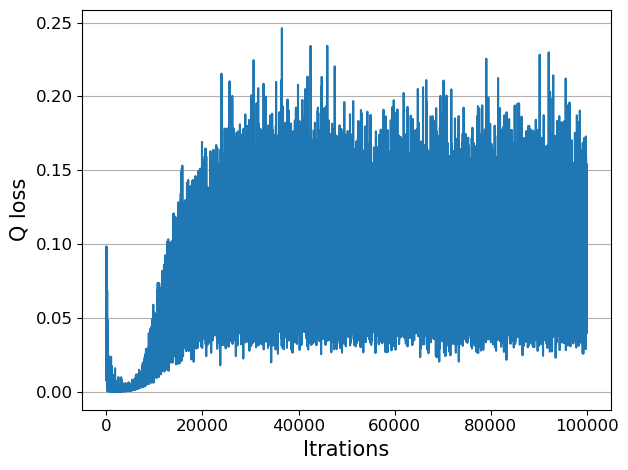

In [11]:
plt.plot(critic.get_current_loss())
plt.xlabel("Itrations", fontsize=15)
plt.ylabel("Q loss", fontsize=15)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis="y")
plt.tight_layout()

In [35]:
p = 67
torch.round(n_rewards[0, p].cpu(), decimals=2), torch.round(k_rewards[p].cpu(), decimals=2)

(tensor([-0.0000, -0.0000, 0.0100, 0.0200, 0.7800, -0.0000]),
 tensor([-0.0000,  0.0000, -0.0100,  0.0100,  0.8200,  0.0000]))

In [36]:
sampled_batch["mdp_obs"][p][1:5, center_indx, center_indx], sampled_batch["mon_obs"][p]

(tensor([0.5000, 0.5000, 0.0000, 0.5000], device='mps:0'),
 tensor([1.], device='mps:0'))

In [37]:
qs[p], policy[p], torch.argmax(qs[p], 0)

(tensor([8.2317, 8.2885, 8.2986, 8.3797, 8.6076, 8.3276], device='mps:0'),
 tensor([0.1461, 0.1547, 0.1562, 0.1694, 0.2128, 0.1608], device='mps:0'),
 tensor(4, device='mps:0'))

In [26]:
sampled_batch = replay_buffer_3.process_batch(replay_buffer_3.sample(20000), device=device)
unmonitor_ind= np.where(sampled_batch["mon_obs"].cpu().numpy() == 1)[0]
plant_channels = sampled_batch["mdp_obs"][unmonitor_ind][:, 1:4, center_indx, center_indx].cpu().numpy()

In [27]:
plant_indx = []
cactus_indx = []
diff_1_indx, diff_2_indx, diff_3_indx, diff_4_indx, diff_5_indx = [], [], [], [], []
for i, row in enumerate(plant_channels):
    if (row == np.array([0, 1, 1]) / 2).all():
        cactus_indx.append(i)
    if (row == np.array([1, 1, 0]) / 2).all():
        plant_indx.append(i)
    if (row == np.array([0, 0, 1])).all():
        diff_1_indx.append(i)
    if (row == np.array([0, 1, 0])).all():
        diff_2_indx.append(i)
    if (row == np.array([1, 0, 0])).all():
        diff_3_indx.append(i)
    if (row == np.array([1, 0, 1]) / 2).all():
        diff_4_indx.append(i)
    if (np.allclose(row , np.array([1, 1, 1]) / 3):
        diff_5_indx.append(i)
len(plant_indx), len(cactus_indx), len(diff_1_indx), len(diff_2_indx), len(diff_3_indx), len(diff_4_indx), len(diff_5_indx)

(1509, 706, 5, 5, 16, 2, 0)

In [31]:
with torch.no_grad():
    qs = critic._q_network.forward(sampled_batch["mdp_obs"][unmonitor_ind][diff_4_indx],
                                   sampled_batch["mon_obs"][unmonitor_ind][diff_4_indx])
torch.argmax(torch.softmax(qs, 1), 1)

tensor([3, 0], device='mps:0')

### demo

In [ ]:
q_model = torch.load(main_dir +"/checkpoints_{}/q_network_4".format(4))
# q_model = torch.load(main_dir +"/q_network_3")
r_model = torch.load(main_dir +"/checkpoints_{}/reward_model_4".format(5))

In [ ]:
ep_reward = []
for i in range(1):
    s, _ = env.reset()
    total_r, timestep, spill, cactus, water_plant = 0, 0, 0, 0, 0
    done = False
    actions, mdp_s, mon_s = [], [], []
    cactus_obs, plants_obs = [], []
    action_probs = []
    env.render()
    while timestep < 100:
        mdp_obs = torch.tensor(s["mdp"], dty pe=torch.float32, device=device).unsqueeze(0)
        mon_obs = torch.tensor([s["monitor"]], dtype=torch.float32, device=device).unsqueeze(0)
        mdp_s.append(mdp_obs)
        mon_s.append(mon_obs)

        with torch.no_grad():
            # q_values = critic._q_network.forward(mdp_obs, mon_obs)
            q_values = q_model[5:](torch.concat((q_model[:5](mdp_obs), mon_obs), 1))
        action = select_action(q_values.cpu().numpy().squeeze())
        
        actions.append(action)
        plant = env.get_grid()[1, env.get_agent_pos()[0], env.get_agent_pos()[1]]
        if plant == 0.5:
            cactus_obs.append(mdp_obs)
        if plant == 1:
            plants_obs.append(mdp_obs)
        s, r, done, _, info = env.step({"mdp": action, "monitor": 0})
        if action == 4:
            if plant == 0.0:  # spill water in the floor
                spill += 1
            if plant == 0.5: # water cactus
                cactus += 1
                print("r", info["mdp_reward"])
            else:
                water_plant += 1
        reward = info["mdp_reward"] + r["monitor"]
        total_r += reward * (gamma**timestep)
        timestep += 1
        env.render()
    ep_reward.append(total_r)
    print("spill", spill)
    print("cactus", cactus)
    print("water_plant", water_plant)
actions = np.squeeze(actions)
# env.close()

In [ ]:
mdp_obs[0, 1:4]

In [37]:
tmp = mdp_s[-1][:, :, center_indx, center_indx]
tmp, torch.round(r_model(tmp).cpu(), decimals=2)

(tensor([[1.0000, 1.0000, 1.0000, 1.0000, 0.5000, 0.0000]], device='mps:0'),
 tensor([[-0.0000, -0.0000, 0.0000, -0.0000, 0.0600, -0.0000]],
        grad_fn=<RoundBackward1>))

In [30]:
mdp_s[3][0, 1:4, center_indx, center_indx]

tensor([1., 1., 1.], device='mps:0')

In [15]:
torch.softmax(q_values, 1), action, mon_obs

(tensor([[0.1727, 0.1776, 0.1719, 0.1712, 0.1286, 0.1780]], device='mps:0'),
 5,
 tensor([[1.]], device='mps:0'))

In [77]:

# Creating a gif from the images
from PIL import Image

# Creating a directory for GIFs
path_to_gifs = "q-learning-animation"
os.makedirs(path_to_gifs, exist_ok=True)

def create_gif(image_dir: str, output_filename: str, duration: int = 300):
    images = []
    image_files = os.listdir(image_dir)
    image_files.sort(key=lambda x: int(x.split("_")[1].split(".")[0]))
    for file in image_files:
        images.append(Image.open(os.path.join(image_dir, file)))
    images[0].save(
        output_filename,
        save_all=True,
        append_images=images[1:],
        duration=duration,
        loop=0
    )

In [12]:
np.random.choice([i / 8 for i in [1, 2, 3, 5, 6, 7]], 4)

array([0.875, 0.875, 0.625, 0.75 ])

In [33]:
b*a

tensor([[ 2.,  4.,  6.],
        [ 8., 10., 12.]])